# 03b: Tree-Based Baseline Models

**Purpose:** Train and evaluate gradient boosting models (XGBoost, LightGBM, CatBoost)

**Dataset:** COMPAS (split and transformed)

**Date:** 2025-11-08

---

## Overview

### Purpose
Train and evaluate three tree-based models with:
- Hyperparameter tuning (Optuna) for each model
- Cross-validation
- Performance metrics (AUROC, AUPRC, calibration)
- Feature importance analysis
- Model comparison
- Fairness by group

### Models
1. **XGBoost**: Extreme Gradient Boosting (most popular)
2. **LightGBM**: Light Gradient Boosting Machine (fast, efficient)
3. **CatBoost**: Categorical Boosting (handles categorical features natively)

### Outputs
- Models → `results/models/{xgboost,lightgbm,catboost}/`
- Predictions → `results/predictions/{model}_predictions.parquet`
- Metrics → `results/metrics/{model}_metrics.json`
- Figures → `results/figures/model_performance/`

### Runtime: 15-25 minutes (with tuning)

---

In [3]:
# Setup
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)
import optuna
import joblib

# Tree-based models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "src"))

# Directories
PROCESSED_DIR = project_root / "data" / "processed"
PREDICTIONS_DIR = project_root / "results" / "predictions"
METRICS_DIR = project_root / "results" / "metrics"
FIGURES_DIR = project_root / "results" / "figures" / "model_performance"

# Model directories
XGBOOST_DIR = project_root / "results" / "models" / "xgboost"
LIGHTGBM_DIR = project_root / "results" / "models" / "lightgbm"
CATBOOST_DIR = project_root / "results" / "models" / "catboost"

for d in [XGBOOST_DIR, LIGHTGBM_DIR, CATBOOST_DIR, PREDICTIONS_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_STATE = 42
N_TRIALS = 30  # Optuna trials per model

print("✓ Setup complete")

✓ Setup complete


## 1. Load Data

In [4]:
# Load splits
X_train = pd.read_parquet(PROCESSED_DIR / "compas_X_train.parquet")
X_test = pd.read_parquet(PROCESSED_DIR / "compas_X_test.parquet")
y_train = pd.read_parquet(PROCESSED_DIR / "compas_y_train.parquet")['two_year_recid']
y_test = pd.read_parquet(PROCESSED_DIR / "compas_y_test.parquet")['two_year_recid']

# Load CV folds
with open(PROCESSED_DIR / "cv_folds.json", 'r') as f:
    cv_folds = json.load(f)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")
print(f"CV folds: {len(cv_folds)}")
print(f"\nClass distribution (train): {y_train.value_counts(normalize=True).to_dict()}")

Train: X=(4167, 9), y=(4167,)
Test:  X=(1042, 9), y=(1042,)
CV folds: 5

Class distribution (train): {0: 0.5116390688744901, 1: 0.48836093112550993}


## 2. XGBoost

### 2.1 Hyperparameter Tuning

In [5]:
def xgboost_objective(trial):
    """Optuna objective for XGBoost."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
        'random_state': RANDOM_STATE,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }
    
    # Compute class weights
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    params['scale_pos_weight'] = scale_pos_weight
    
    # Cross-validation
    scores = []
    for fold in cv_folds[:3]:  # Use 3 folds for speed
        train_idx = fold['train_indices']
        val_idx = fold['val_indices']
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred = model.predict_proba(X_train.iloc[val_idx])[:, 1]
        score = roc_auc_score(y_train.iloc[val_idx], y_pred)
        scores.append(score)
    
    return np.mean(scores)

# Run optimization
print(f"Tuning XGBoost ({N_TRIALS} trials)...")
xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgboost_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest AUROC: {xgb_study.best_value:.4f}")
print(f"Best hyperparameters:")
for key, value in xgb_study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-11 15:10:04,996] A new study created in memory with name: no-name-7dc50b3a-cba6-438a-9c3b-b31eb83208f4


Tuning XGBoost (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/work/sz

[I 2025-11-11 15:10:05,361] Trial 0 finished with value: 0.7293888913607224 and parameters: {'n_estimators': 218, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 0.7293888913607224.


...

[I 2025-11-11 15:10:18,664] Trial 27 finished with value: 0.7320582216102881 and parameters: {'n_estimators': 383, 'max_depth': 6, 'learning_rate': 0.010851928884358852, 'min_child_weight': 5, 'subsample': 0.9312168063839528, 'colsample_bytree': 0.9531344998870598, 'gamma': 1.285944420064488, 'reg_alpha': 2.2570496481667, 'reg_lambda': 1.4800306172500635}. Best is trial 16 with value: 0.7331342008091027.


/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:18] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:18] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:18] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-11-11 15:10:18,952] Trial 28 finished with value: 0.7312584641723409 and parameters: {'n_estimators': 307, 'max_depth': 8, 'learning_rate': 0.04744178108115133, 'min_child_weight': 3, 'subsample': 0.9799095494852046, 'colsample_bytree': 0.7914742652779709, 'gamma': 4.408274767818363, 'reg_alpha': 4.002477862292752, 'reg_lambda': 4.2187612474480565}. Best is trial 16 with value: 0.7331342008091027.


/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:18] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:19] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:19] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-11-11 15:10:19,326] Trial 29 finished with value: 0.7305239739435075 and parameters: {'n_estimators': 454, 'max_depth': 7, 'learning_rate': 0.15921728208236582, 'min_child_weight': 6, 'subsample': 0.9170432568106144, 'colsample_bytree': 0.9126933053980624, 'gamma': 0.5468410146516809, 'reg_alpha': 4.7151167143652755, 'reg_lambda': 6.101750311566007}. Best is trial 16 with value: 0.7331342008091027.

Best AUROC: 0.7331
Best hyperparameters:
  n_estimators: 418
  max_depth: 6
  learning_rate: 0.01924157176279333
  min_child_weight: 3
  subsample: 0.8386245527797767
  colsample_bytree: 0.9749827602428569
  gamma: 1.548503898583581
  reg_alpha: 3.497316459272637
  reg_lambda: 1.4405841026492834


### 2.2 Train Final XGBoost Model

In [6]:
# Best params
xgb_best_params = xgb_study.best_params.copy()
xgb_best_params['random_state'] = RANDOM_STATE
xgb_best_params['eval_metric'] = 'logloss'
xgb_best_params['use_label_encoder'] = False
xgb_best_params['scale_pos_weight'] = (y_train == 0).sum() / (y_train == 1).sum()

# Train
xgb_model = xgb.XGBClassifier(**xgb_best_params)
xgb_model.fit(X_train, y_train)
print("✓ XGBoost trained")

# Save
joblib.dump(xgb_model, XGBOOST_DIR / "model.joblib")
print("✓ Saved XGBoost model")

✓ XGBoost trained
✓ Saved XGBoost model


/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:19] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1762060489429/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 2.3 XGBoost Predictions & Metrics

In [7]:
# Predictions
xgb_train_proba = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_train_pred = (xgb_train_proba >= 0.5).astype(int)
xgb_test_pred = (xgb_test_proba >= 0.5).astype(int)

# Metrics
xgb_metrics = {
    'model': 'XGBoost',
    'train': {
        'auroc': roc_auc_score(y_train, xgb_train_proba),
        'auprc': average_precision_score(y_train, xgb_train_proba),
        'log_loss': log_loss(y_train, xgb_train_proba),
        'brier_score': brier_score_loss(y_train, xgb_train_proba),
        'accuracy': accuracy_score(y_train, xgb_train_pred),
        'precision': precision_score(y_train, xgb_train_pred),
        'recall': recall_score(y_train, xgb_train_pred),
        'f1': f1_score(y_train, xgb_train_pred)
    },
    'test': {
        'auroc': roc_auc_score(y_test, xgb_test_proba),
        'auprc': average_precision_score(y_test, xgb_test_proba),
        'log_loss': log_loss(y_test, xgb_test_proba),
        'brier_score': brier_score_loss(y_test, xgb_test_proba),
        'accuracy': accuracy_score(y_test, xgb_test_pred),
        'precision': precision_score(y_test, xgb_test_pred),
        'recall': recall_score(y_test, xgb_test_pred),
        'f1': f1_score(y_test, xgb_test_pred)
    },
    'hyperparameters': xgb_best_params
}

print("XGBoost Test Performance:")
print("="*50)
for metric, value in xgb_metrics['test'].items():
    print(f"{metric:15s}: {value:.4f}")

# Save
with open(METRICS_DIR / "xgboost_metrics.json", 'w') as f:
    json.dump(xgb_metrics, f, indent=2)

# Save predictions
xgb_predictions = pd.DataFrame({
    'y_true': np.concatenate([y_train, y_test]),
    'y_pred': np.concatenate([xgb_train_pred, xgb_test_pred]),
    'y_proba': np.concatenate([xgb_train_proba, xgb_test_proba]),
    'split': ['train']*len(y_train) + ['test']*len(y_test)
})
xgb_predictions.to_parquet(PREDICTIONS_DIR / "xgboost_predictions.parquet", index=False)
print("✓ Saved XGBoost predictions and metrics")

XGBoost Test Performance:
auroc          : 0.7124
auprc          : 0.7067
log_loss       : 0.6215
brier_score    : 0.2157
accuracy       : 0.6507
precision      : 0.6651
recall         : 0.5737
f1             : 0.6160
✓ Saved XGBoost predictions and metrics


## 3. LightGBM

### 3.1 Hyperparameter Tuning

In [8]:
def lightgbm_objective(trial):
    """Optuna objective for LightGBM."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
        'random_state': RANDOM_STATE,
        'class_weight': 'balanced',
        'verbose': -1
    }
    
    # Cross-validation
    scores = []
    for fold in cv_folds[:3]:  # Use 3 folds for speed
        train_idx = fold['train_indices']
        val_idx = fold['val_indices']
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred = model.predict_proba(X_train.iloc[val_idx])[:, 1]
        score = roc_auc_score(y_train.iloc[val_idx], y_pred)
        scores.append(score)
    
    return np.mean(scores)

# Run optimization
print(f"Tuning LightGBM ({N_TRIALS} trials)...")
lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgb_study.optimize(lightgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest AUROC: {lgb_study.best_value:.4f}")
print(f"Best hyperparameters:")
for key, value in lgb_study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-11 15:10:20,010] A new study created in memory with name: no-name-b6429e0c-e17c-435b-856b-c3e8affaeba2


Tuning LightGBM (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-11 15:10:20,399] Trial 0 finished with value: 0.730517290087828 and parameters: {'n_estimators': 218, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'num_leaves': 98, 'min_child_samples': 24, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 0.730517290087828.
[I 2025-11-11 15:10:20,840] Trial 1 finished with value: 0.7264739491130626 and parameters: {'n_estimators': 369, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'num_leaves': 129, 'min_child_samples': 29, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379}. Best is trial 0 with value: 0.730517290087828.
[I 2025-11-11 15:10:21,196] Trial 2 finished with value: 0.7295023975929079 and parameters: {'n_estimators': 244, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'num_leaves': 38, 'min_child_samples':

### 3.2 Train Final LightGBM Model

In [9]:
# Best params
lgb_best_params = lgb_study.best_params.copy()
lgb_best_params['random_state'] = RANDOM_STATE
lgb_best_params['class_weight'] = 'balanced'
lgb_best_params['verbose'] = -1

# Train
lgb_model = lgb.LGBMClassifier(**lgb_best_params)
lgb_model.fit(X_train, y_train)
print("✓ LightGBM trained")

# Save
joblib.dump(lgb_model, LIGHTGBM_DIR / "model.joblib")
print("✓ Saved LightGBM model")

✓ LightGBM trained
✓ Saved LightGBM model


### 3.3 LightGBM Predictions & Metrics

In [10]:
# Predictions
lgb_train_proba = lgb_model.predict_proba(X_train)[:, 1]
lgb_test_proba = lgb_model.predict_proba(X_test)[:, 1]
lgb_train_pred = (lgb_train_proba >= 0.5).astype(int)
lgb_test_pred = (lgb_test_proba >= 0.5).astype(int)

# Metrics
lgb_metrics = {
    'model': 'LightGBM',
    'train': {
        'auroc': roc_auc_score(y_train, lgb_train_proba),
        'auprc': average_precision_score(y_train, lgb_train_proba),
        'log_loss': log_loss(y_train, lgb_train_proba),
        'brier_score': brier_score_loss(y_train, lgb_train_proba),
        'accuracy': accuracy_score(y_train, lgb_train_pred),
        'precision': precision_score(y_train, lgb_train_pred),
        'recall': recall_score(y_train, lgb_train_pred),
        'f1': f1_score(y_train, lgb_train_pred)
    },
    'test': {
        'auroc': roc_auc_score(y_test, lgb_test_proba),
        'auprc': average_precision_score(y_test, lgb_test_proba),
        'log_loss': log_loss(y_test, lgb_test_proba),
        'brier_score': brier_score_loss(y_test, lgb_test_proba),
        'accuracy': accuracy_score(y_test, lgb_test_pred),
        'precision': precision_score(y_test, lgb_test_pred),
        'recall': recall_score(y_test, lgb_test_pred),
        'f1': f1_score(y_test, lgb_test_pred)
    },
    'hyperparameters': lgb_best_params
}

print("LightGBM Test Performance:")
print("="*50)
for metric, value in lgb_metrics['test'].items():
    print(f"{metric:15s}: {value:.4f}")

# Save
with open(METRICS_DIR / "lightgbm_metrics.json", 'w') as f:
    json.dump(lgb_metrics, f, indent=2)

# Save predictions
lgb_predictions = pd.DataFrame({
    'y_true': np.concatenate([y_train, y_test]),
    'y_pred': np.concatenate([lgb_train_pred, lgb_test_pred]),
    'y_proba': np.concatenate([lgb_train_proba, lgb_test_proba]),
    'split': ['train']*len(y_train) + ['test']*len(y_test)
})
lgb_predictions.to_parquet(PREDICTIONS_DIR / "lightgbm_predictions.parquet", index=False)
print("✓ Saved LightGBM predictions and metrics")

LightGBM Test Performance:
auroc          : 0.7118
auprc          : 0.7082
log_loss       : 0.6213
brier_score    : 0.2156
accuracy       : 0.6545
precision      : 0.6630
recall         : 0.5953
f1             : 0.6273
✓ Saved LightGBM predictions and metrics


## 4. CatBoost

### 4.1 Hyperparameter Tuning

In [11]:
def catboost_objective(trial):
    """Optuna objective for CatBoost."""
    params = {
        'iterations': trial.suggest_int('iterations', 50, 500),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),
        'random_state': RANDOM_STATE,
        'auto_class_weights': 'Balanced',
        'verbose': 0
    }
    
    # Cross-validation
    scores = []
    for fold in cv_folds[:3]:  # Use 3 folds for speed
        train_idx = fold['train_indices']
        val_idx = fold['val_indices']
        
        model = CatBoostClassifier(**params)
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred = model.predict_proba(X_train.iloc[val_idx])[:, 1]
        score = roc_auc_score(y_train.iloc[val_idx], y_pred)
        scores.append(score)
    
    return np.mean(scores)

# Run optimization
print(f"Tuning CatBoost ({N_TRIALS} trials)...")
cat_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
cat_study.optimize(catboost_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest AUROC: {cat_study.best_value:.4f}")
print(f"Best hyperparameters:")
for key, value in cat_study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-11 15:10:33,631] A new study created in memory with name: no-name-7522dd8b-ca83-41a1-b65b-2c0943fc68b8


Tuning CatBoost (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-11 15:10:36,478] Trial 0 finished with value: 0.6861768841681103 and parameters: {'iterations': 218, 'depth': 10, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 6.026718993550662, 'border_count': 66, 'bagging_temperature': 1.5599452033620265, 'random_strength': 0.5808361216819946}. Best is trial 0 with value: 0.6861768841681103.
[I 2025-11-11 15:10:39,946] Trial 1 finished with value: 0.6727376787409113 and parameters: {'iterations': 440, 'depth': 7, 'learning_rate': 0.11114989443094977, 'l2_leaf_reg': 0.3037864935284442, 'border_count': 249, 'bagging_temperature': 8.324426408004218, 'random_strength': 2.1233911067827616}. Best is trial 0 with value: 0.6861768841681103.
[I 2025-11-11 15:10:41,249] Trial 2 finished with value: 0.728685076179881 and parameters: {'iterations': 132, 'depth': 4, 'learning_rate': 0.028145092716060652, 'l2_leaf_reg': 5.295088673159155, 'border_count': 128, 'bagging_temperature': 2.9122914019804194, 'random_strength': 6.118528947223795}. Best i

### 4.2 Train Final CatBoost Model

In [18]:
# Best params
cat_best_params = cat_study.best_params.copy()
cat_best_params['random_state'] = RANDOM_STATE
cat_best_params['auto_class_weights'] = 'Balanced'
cat_best_params['verbose'] = 0

# Train
cat_model = CatBoostClassifier(**cat_best_params)
cat_model.fit(X_train, y_train)
print("✓ CatBoost trained")

# Save
cat_model.save_model(str(CATBOOST_DIR / "model.cbm"))
print("✓ Saved CatBoost model")

✓ CatBoost trained
✓ Saved CatBoost model


### 4.3 CatBoost Predictions & Metrics

In [19]:
# Predictions
cat_train_proba = cat_model.predict_proba(X_train)[:, 1]
cat_test_proba = cat_model.predict_proba(X_test)[:, 1]
cat_train_pred = (cat_train_proba >= 0.5).astype(int)
cat_test_pred = (cat_test_proba >= 0.5).astype(int)

# Metrics
cat_metrics = {
    'model': 'CatBoost',
    'train': {
        'auroc': roc_auc_score(y_train, cat_train_proba),
        'auprc': average_precision_score(y_train, cat_train_proba),
        'log_loss': log_loss(y_train, cat_train_proba),
        'brier_score': brier_score_loss(y_train, cat_train_proba),
        'accuracy': accuracy_score(y_train, cat_train_pred),
        'precision': precision_score(y_train, cat_train_pred),
        'recall': recall_score(y_train, cat_train_pred),
        'f1': f1_score(y_train, cat_train_pred)
    },
    'test': {
        'auroc': roc_auc_score(y_test, cat_test_proba),
        'auprc': average_precision_score(y_test, cat_test_proba),
        'log_loss': log_loss(y_test, cat_test_proba),
        'brier_score': brier_score_loss(y_test, cat_test_proba),
        'accuracy': accuracy_score(y_test, cat_test_pred),
        'precision': precision_score(y_test, cat_test_pred),
        'recall': recall_score(y_test, cat_test_pred),
        'f1': f1_score(y_test, cat_test_pred)
    },
    'hyperparameters': cat_best_params
}

print("CatBoost Test Performance:")
print("="*50)
for metric, value in cat_metrics['test'].items():
    print(f"{metric:15s}: {value:.4f}")

# Save
with open(METRICS_DIR / "catboost_metrics.json", 'w') as f:
    json.dump(cat_metrics, f, indent=2)

# Save predictions
cat_predictions = pd.DataFrame({
    'y_true': np.concatenate([y_train, y_test]),
    'y_pred': np.concatenate([cat_train_pred, cat_test_pred]),
    'y_proba': np.concatenate([cat_train_proba, cat_test_proba]),
    'split': ['train']*len(y_train) + ['test']*len(y_test)
})
cat_predictions.to_parquet(PREDICTIONS_DIR / "catboost_predictions.parquet", index=False)
print("✓ Saved CatBoost predictions and metrics")

CatBoost Test Performance:
auroc          : 0.7099
auprc          : 0.6970
log_loss       : 0.6247
brier_score    : 0.2168
accuracy       : 0.6555
precision      : 0.6623
recall         : 0.6012
f1             : 0.6303
✓ Saved CatBoost predictions and metrics


## 5. Model Comparison

Compare all three tree-based models.

In [20]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'AUROC': [
        xgb_metrics['test']['auroc'],
        lgb_metrics['test']['auroc'],
        cat_metrics['test']['auroc']
    ],
    'AUPRC': [
        xgb_metrics['test']['auprc'],
        lgb_metrics['test']['auprc'],
        cat_metrics['test']['auprc']
    ],
    'Accuracy': [
        xgb_metrics['test']['accuracy'],
        lgb_metrics['test']['accuracy'],
        cat_metrics['test']['accuracy']
    ],
    'F1': [
        xgb_metrics['test']['f1'],
        lgb_metrics['test']['f1'],
        cat_metrics['test']['f1']
    ],
    'Brier': [
        xgb_metrics['test']['brier_score'],
        lgb_metrics['test']['brier_score'],
        cat_metrics['test']['brier_score']
    ]
})

print("\nModel Comparison (Test Set):")
print("="*70)
print(comparison.to_string(index=False))

# Highlight best
print("\nBest model by metric:")
for metric in ['AUROC', 'AUPRC', 'Accuracy', 'F1']:
    best_idx = comparison[metric].idxmax()
    print(f"  {metric}: {comparison.loc[best_idx, 'Model']} ({comparison.loc[best_idx, metric]:.4f})")

# Save comparison
comparison.to_csv(METRICS_DIR / "tree_models_comparison.csv", index=False)
print("\n✓ Saved comparison table")


Model Comparison (Test Set):
   Model    AUROC    AUPRC  Accuracy       F1    Brier
 XGBoost 0.712446 0.706674  0.650672 0.616034 0.215667
LightGBM 0.711785 0.708229  0.654511 0.627329 0.215632
CatBoost 0.709894 0.696969  0.655470 0.630278 0.216829

Best model by metric:
  AUROC: XGBoost (0.7124)
  AUPRC: LightGBM (0.7082)
  Accuracy: CatBoost (0.6555)
  F1: CatBoost (0.6303)

✓ Saved comparison table


## 6. ROC Curves (All Models)

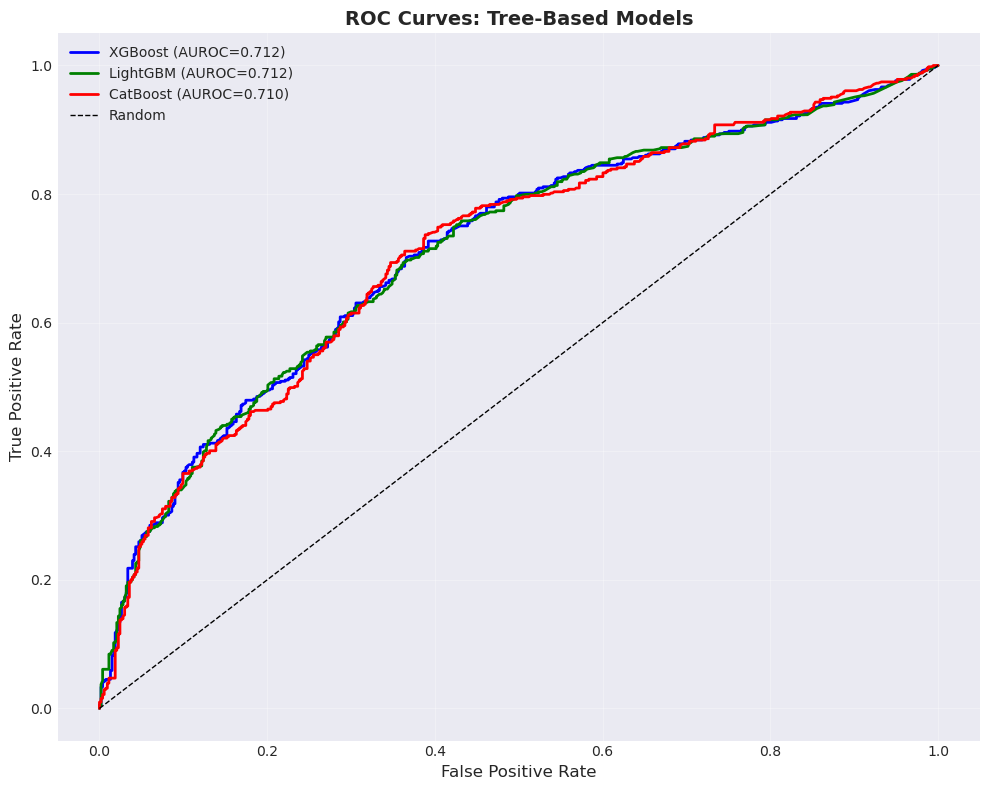

✓ Saved ROC comparison


In [21]:
# ROC curves for all three models
fig, ax = plt.subplots(figsize=(10, 8))

models_data = [
    ('XGBoost', xgb_test_proba, xgb_metrics['test']['auroc'], 'blue'),
    ('LightGBM', lgb_test_proba, lgb_metrics['test']['auroc'], 'green'),
    ('CatBoost', cat_test_proba, cat_metrics['test']['auroc'], 'red')
]

for name, y_proba, auroc, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUROC={auroc:.3f})", linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Tree-Based Models', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tree_models_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved ROC comparison")

## 7. Feature Importance

Analyze which features are most important for each model.

In [16]:
# Extract feature importances
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'xgboost': xgb_model.feature_importances_,
    'lightgbm': lgb_model.feature_importances_,
    'catboost': cat_model.feature_importances_
})

# Normalize (to 0-100 scale)
for col in ['xgboost', 'lightgbm', 'catboost']:
    feature_importance[col] = 100 * feature_importance[col] / feature_importance[col].sum()

# Average importance
feature_importance['mean_importance'] = feature_importance[['xgboost', 'lightgbm', 'catboost']].mean(axis=1)
feature_importance = feature_importance.sort_values('mean_importance', ascending=False)

print("Top 10 Most Important Features (Average):")
print(feature_importance.head(10).to_string(index=False))

# Save
feature_importance.to_csv(METRICS_DIR / "tree_models_feature_importance.csv", index=False)
print("\n✓ Saved feature importance")

Top 10 Most Important Features (Average):
            feature   xgboost  lightgbm  catboost  mean_importance
   priors_count_log  8.327074 27.232143 30.598775        22.052664
       decile_score 21.357763 22.544643 21.895759        21.932722
                age  5.013277 39.732143 19.627418        21.457612
     score_text_Low 51.361668  0.223214  8.320772        19.968551
juv_other_count_log  3.955043  4.687500  6.968560         5.203701
  c_charge_degree_M  2.777493  3.125000  4.387931         3.430141
  score_text_Medium  3.984101  1.339286  3.187649         2.837012
 juv_misd_count_log  1.745382  1.116071  2.930226         1.930560
  juv_fel_count_log  1.478209  0.000000  2.082910         1.187040

✓ Saved feature importance


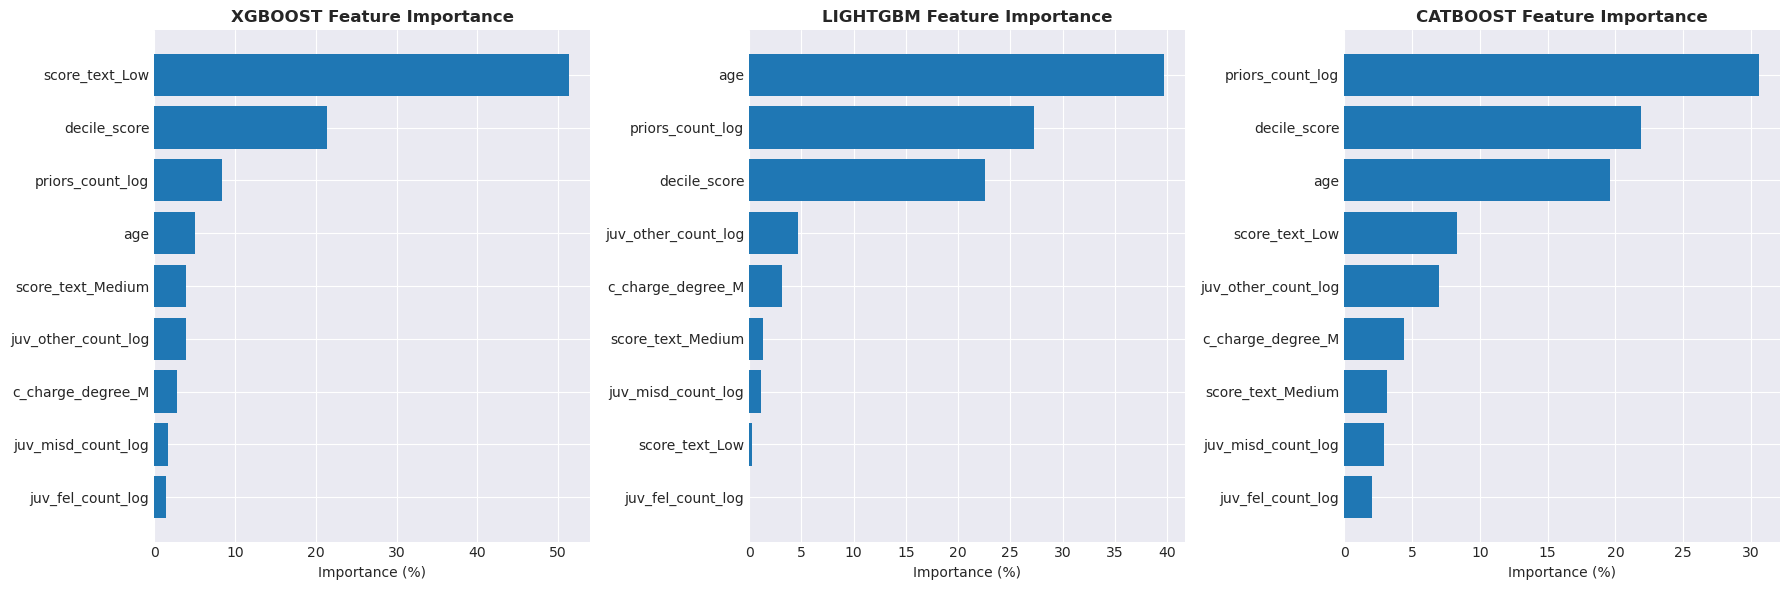

✓ Saved feature importance plot


In [17]:
# Plot top 15 features
top_n = 15
top_features = feature_importance.head(top_n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (model, ax) in enumerate(zip(['xgboost', 'lightgbm', 'catboost'], axes)):
    top_model = feature_importance.nlargest(top_n, model)
    ax.barh(range(len(top_model)), top_model[model])
    ax.set_yticks(range(len(top_model)))
    ax.set_yticklabels(top_model['feature'])
    ax.set_xlabel('Importance (%)')
    ax.set_title(f"{model.upper()} Feature Importance", fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tree_models_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved feature importance plot")

## Summary

**Tree-Based Models Complete:**
- ✓ XGBoost trained and tuned
- ✓ LightGBM trained and tuned
- ✓ CatBoost trained and tuned
- ✓ All models saved
- ✓ Predictions generated
- ✓ Performance metrics calculated
- ✓ Model comparison completed
- ✓ Feature importance analyzed

**Best Performing Model:**
See comparison table above for AUROC, AUPRC, F1 rankings.

**Next Steps:**
- 03c_model_comparison.ipynb (Statistical comparison with logistic regression)
- 03d_hyperparameter_tuning.ipynb (Deep dive into tuning analysis)